# Module 2 — Predicting Ad Clicks with a Neural Network

**Scenario:** You're a data scientist at an ad agency. A client wants to know: *which users are likely to click on their online ads?*  
If you can predict that, the agency can target ads better and save money by not showing ads to people who'll never click.

**The plan:**
1. Load and explore the data
2. Clean it up and pick the right features
3. Split into train/test sets (80/20)
4. Build an Artificial Neural Network (ANN) classifier
5. Try a few different setups to see what works best
6. Report the final numbers and explain what matters most

**Target column:** `Clicked on Ad` — 0 means they didn't click, 1 means they did.

## Step 1 — Import everything we need

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# sklearn handles splitting, scaling, and metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve
)

# TensorFlow / Keras is what we'll use to build the neural network
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# fix randomness so results are reproducible
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


## Step 2 — Load the data and take a first look

In [21]:
github_url = 'https://raw.githubusercontent.com/BPALAN-USD/AAI511/main/Dataset.csv'

df = pd.read_csv(github_url)

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 1000, Columns: 10


,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [22]:
# check data types and see if anything looks off
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [23]:
# quick summary stats — min, max, mean for numeric columns
df.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


In [24]:
# how many nulls do we have?
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line               0
City                        0
Male                        0
Country                     0
Timestamp                   0
Clicked on Ad               0
dtype: int64


In [25]:
# how balanced is the target? if one class has way more rows the model can cheat
print("Click distribution:")
print(df['Clicked on Ad'].value_counts())
print()
print(df['Clicked on Ad'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Click distribution:
Clicked on Ad
0    500
1    500
Name: count, dtype: int64

Clicked on Ad
0    50.0%
1    50.0%
Name: proportion, dtype: object


## Step 3 — Explore the data visually

Before touching the model, it helps to look at how each feature relates to whether someone clicked.

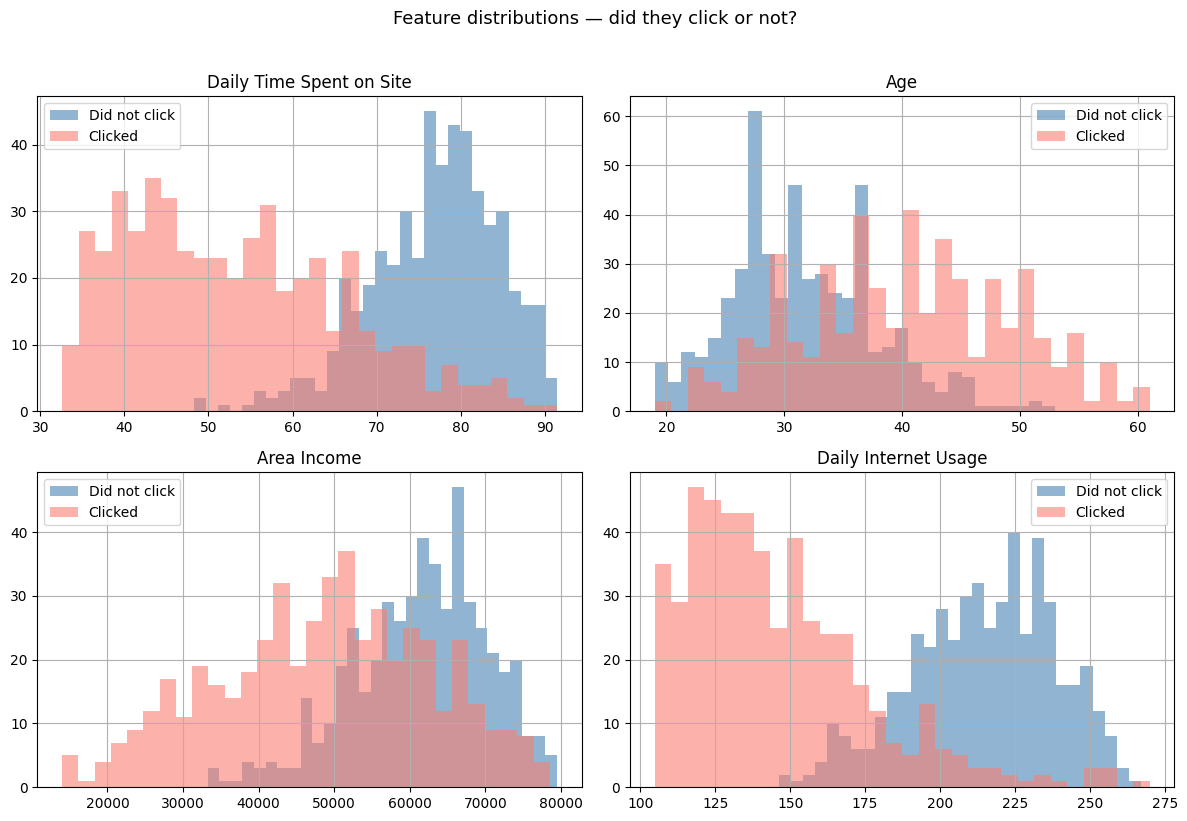

In [26]:
numeric_cols = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[df['Clicked on Ad'] == 0][col].hist(bins=30, alpha=0.6, label='Did not click', ax=axes[i], color='steelblue')
    df[df['Clicked on Ad'] == 1][col].hist(bins=30, alpha=0.6, label='Clicked', ax=axes[i], color='salmon')
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('Feature distributions — did they click or not?', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

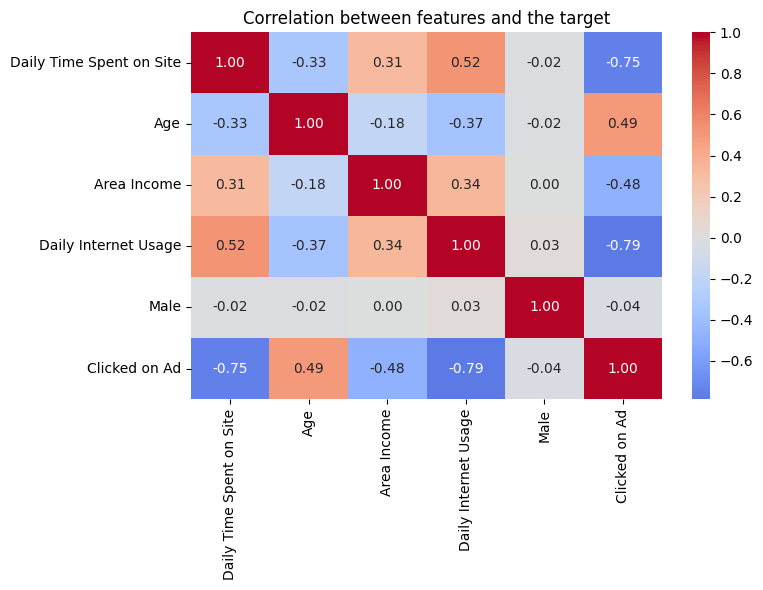

In [27]:
# correlation heatmap — helps spot which features move together
plt.figure(figsize=(8, 6))
corr = df[numeric_cols + ['Male', 'Clicked on Ad']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation between features and the target')
plt.tight_layout()
plt.show()

## Step 4 — Clean up and build features

The columns `Ad Topic Line`, `City`, and `Country` are text with tons of unique values — encoding all of them would blow up the model. We'll drop them.

The `Timestamp` column is a date/time string. Instead of dropping it, we can pull out the **hour of day** and **day of week** — those might matter (people behave differently in the morning vs. evening).

In [28]:
# parse the timestamp so we can extract time-based features
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['hour']        = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.dayofweek   # 0=Monday, 6=Sunday

# drop columns we can't use directly in the model
df_clean = df.drop(columns=['Ad Topic Line', 'City', 'Country', 'Timestamp'])

print("Final columns going into the model:")
print(df_clean.columns.tolist())

Final columns going into the model:
['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male', 'Clicked on Ad', 'hour', 'day_of_week']


In [29]:
# drop any rows with nulls (there shouldn't be many, but just in case)
before = len(df_clean)
df_clean = df_clean.dropna()
after = len(df_clean)
print(f"Dropped {before - after} rows with missing values. {after} rows remain.")

Dropped 0 rows with missing values. 1000 rows remain.


## Step 5 — Split into training and test sets

We hold back 20% of the data for testing. The model never sees the test set during training — it's our honest final check.

In [30]:
feature_cols = ['Daily Time Spent on Site', 'Age', 'Area Income',
                'Daily Internet Usage', 'Male', 'hour', 'day_of_week']

X = df_clean[feature_cols].values
y = df_clean['Clicked on Ad'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")

Training set: 800 rows
Test set:     200 rows


## Step 6 — Scale the features

Neural networks work much better when all inputs are on a similar scale. `Area Income` is in the tens of thousands while `Age` is in the tens — without scaling, the model would overweight income just because the numbers are bigger.

We fit the scaler **only on training data** and then apply it to test data. This prevents data leakage.

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # use the same scaler — don't refit on test data

print("After scaling — mean of each feature in training set (should be ~0):")
print(dict(zip(feature_cols, X_train_scaled.mean(axis=0).round(4))))

After scaling — mean of each feature in training set (should be ~0):
{'Daily Time Spent on Site': np.float64(0.0), 'Age': np.float64(0.0), 'Area Income': np.float64(-0.0), 'Daily Internet Usage': np.float64(-0.0), 'Male': np.float64(-0.0), 'hour': np.float64(-0.0), 'day_of_week': np.float64(0.0)}


## Step 7 — Build three ANN models to compare

We'll try **three different setups** and compare them at the end:

| Model | Architecture | Regularization |
|-------|-------------|----------------|
| Baseline | 64 → 32 → 1 | None |
| Deeper + Dropout | 128 → 64 → 32 → 1 | Dropout |
| L2 Regularized | 64 → 32 → 1 | L2 weight penalty |

All models use **sigmoid** on the output layer (standard for binary yes/no classification).

In [32]:
n_features = X_train_scaled.shape[1]

def build_baseline():
    """simple two-hidden-layer network — nothing fancy"""
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1,  activation='sigmoid')
    ], name='baseline')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_deeper_dropout():
    """deeper network with dropout — randomly zeros out neurons to prevent overfitting"""
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),    # 30% of neurons are randomly turned off each training step
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1,  activation='sigmoid')
    ], name='deeper_with_dropout')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_l2_regularized():
    """same shape as baseline but L2 adds a small penalty for large weights"""
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(1,  activation='sigmoid')
    ], name='l2_regularized')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),  # slightly lower lr with L2
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


# print the baseline architecture so we can see what it looks like
build_baseline().summary()

Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625 (10.25 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

## Step 8 — Train all three models

In [33]:
# early stopping stops training if val_loss doesn't improve for 10 epochs in a row
# this saves time and keeps the best version of the model
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

EPOCHS     = 50
BATCH_SIZE = 32

models_to_train = {
    'Baseline':          build_baseline(),
    'Deeper + Dropout':  build_deeper_dropout(),
    'L2 Regularized':    build_l2_regularized(),
}

histories = {}

for name, model in models_to_train.items():
    print(f"\nTraining: {name}")
    hist = model.fit(
        X_train_scaled, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.15,   # hold out 15% of training data for validation during training
        callbacks=[early_stop],
        verbose=0
    )
    histories[name] = hist
    print(f"  Stopped at epoch {len(hist.history['loss'])}")
    print(f"  Best val accuracy: {max(hist.history['val_accuracy']):.4f}")


Training: Baseline
  Stopped at epoch 23
  Best val accuracy: 0.9667

Training: Deeper + Dropout
  Stopped at epoch 20
  Best val accuracy: 0.9667

Training: L2 Regularized
  Stopped at epoch 10
  Best val accuracy: 0.9667


## Step 9 — Plot training curves

A model that's overfitting will show training accuracy going up while validation accuracy flattens or drops. We want the two lines to stay close together.

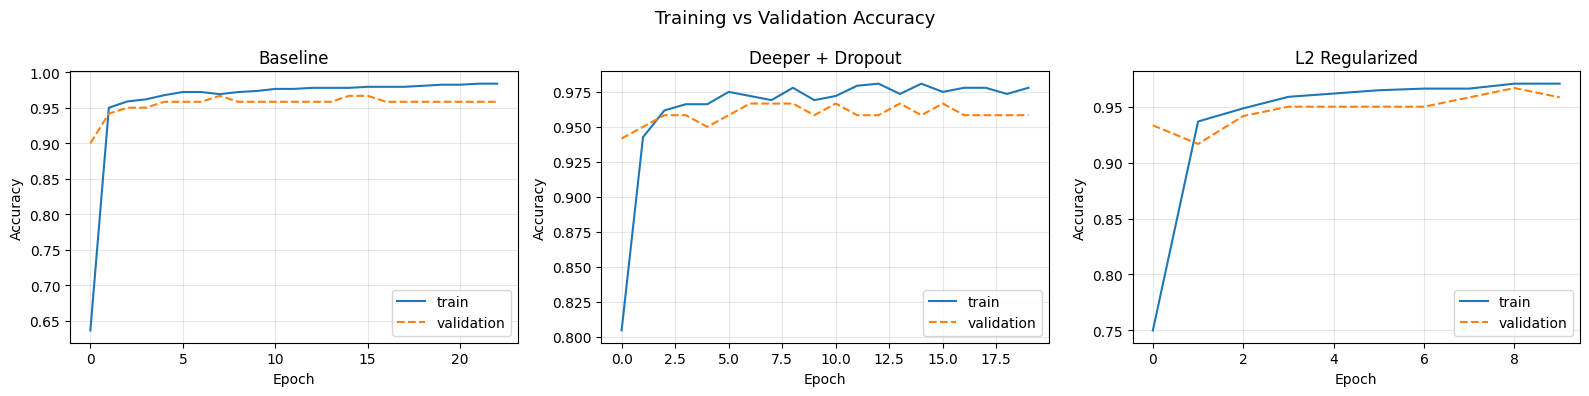

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, hist) in zip(axes, histories.items()):
    ax.plot(hist.history['accuracy'],     label='train')
    ax.plot(hist.history['val_accuracy'], label='validation', linestyle='--')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Training vs Validation Accuracy', fontsize=13)
plt.tight_layout()
plt.show()

## Step 10 — Evaluate on the test set

Now we run each model against the data it has **never seen** and check all five metrics:

- **Accuracy** — overall % of predictions that were correct
- **Precision** — of the users we said would click, how many actually did? (avoids false alarms)
- **Recall** — of all users who actually clicked, how many did we correctly flag? (avoids missed clickers)
- **F1 Score** — harmonic mean of precision and recall (useful when you care about both equally)
- **ROC AUC** — overall ability to rank clickers above non-clickers (1.0 = perfect, 0.5 = coin flip)

In [35]:
results = []

for name, model in models_to_train.items():
    probs = model.predict(X_test_scaled, verbose=0).flatten()
    preds = (probs >= 0.5).astype(int)   # anything above 50% confidence = predicted click

    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall':    recall_score(y_test, preds),
        'F1 Score':  f1_score(y_test, preds),
        'ROC AUC':   roc_auc_score(y_test, probs),
        '_probs':    probs,
    })

results_df = pd.DataFrame(results).drop(columns='_probs')
results_df = results_df.set_index('Model').round(4)
results_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Baseline,0.970,0.9796,0.96,0.9697,0.9913
Deeper + Dropout,0.975,0.9897,0.96,0.9746,0.9896
L2 Regularized,0.920,0.9286,0.91,0.9192,0.9700


## Step 11 — Confusion matrices

The confusion matrix breaks down exactly where the model is right and wrong.  
- Top-left = correctly predicted "no click" ✓  
- Bottom-right = correctly predicted "click" ✓  
- Top-right = said "click" but they didn't (false alarm)  
- Bottom-left = said "no click" but they actually clicked (missed opportunity)

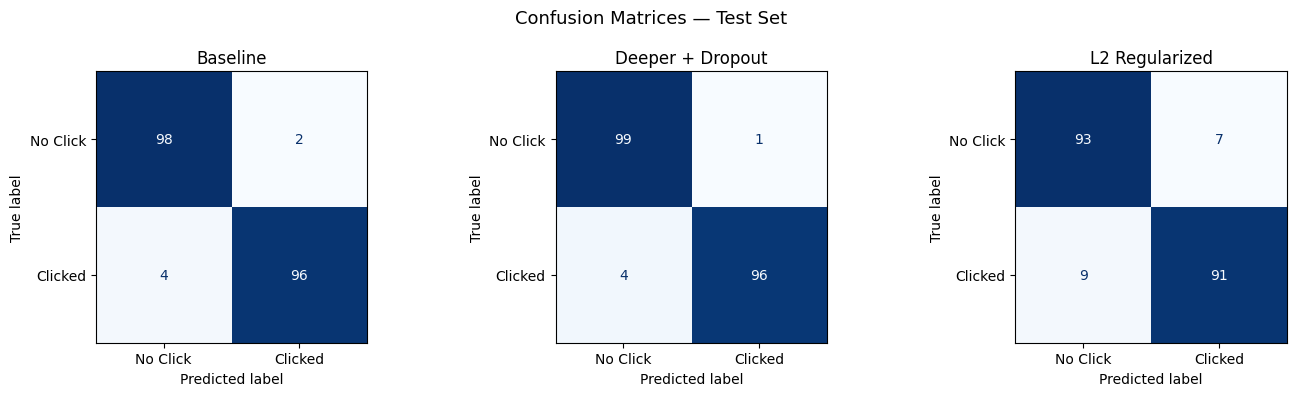

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, model) in zip(axes, models_to_train.items()):
    probs = model.predict(X_test_scaled, verbose=0).flatten()
    preds = (probs >= 0.5).astype(int)
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Click', 'Clicked'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.suptitle('Confusion Matrices — Test Set', fontsize=13)
plt.tight_layout()
plt.show()

## Step 12 — ROC Curves

The ROC curve shows the tradeoff between catching real clickers (true positive rate) and falsely flagging non-clickers (false positive rate). A curve that hugs the top-left corner is better. The diagonal line is what random guessing would look like.

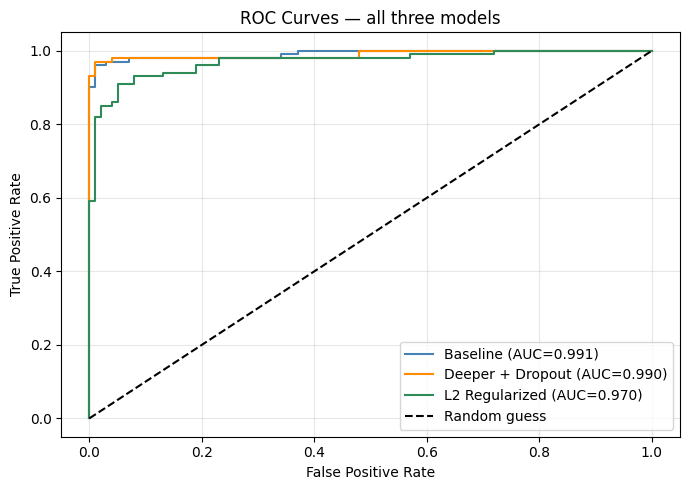

In [37]:
plt.figure(figsize=(7, 5))

colors = ['steelblue', 'darkorange', 'seagreen']
for (name, model), color in zip(models_to_train.items(), colors):
    probs = model.predict(X_test_scaled, verbose=0).flatten()
    auc   = roc_auc_score(y_test, probs)
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color)

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — all three models')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 13 — Which features matter most?

Neural networks don't give you feature importance the same way a decision tree does. A practical workaround: **permutation importance** — shuffle one feature's values at a time (break its relationship with the target) and see how much accuracy drops. Big drop = that feature was doing a lot of heavy lifting.

Using best model: Deeper + Dropout


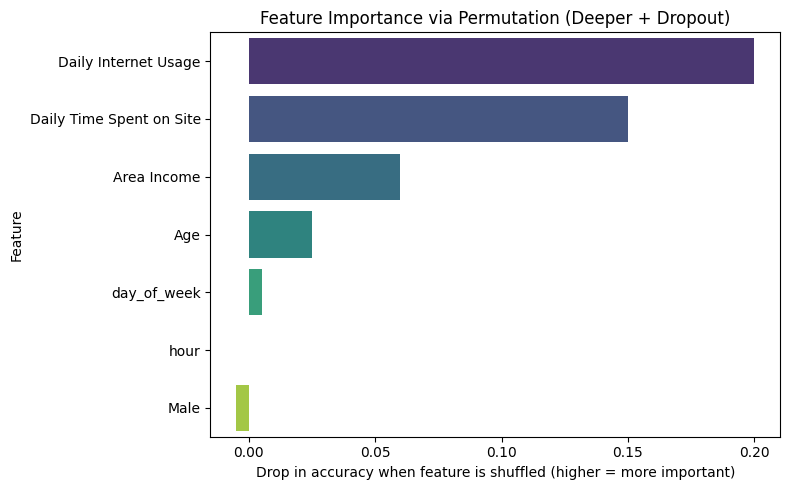

,Feature,Accuracy Drop
0,Daily Internet Usage,0.200
1,Daily Time Spent on Site,0.150
2,Area Income,0.060
3,Age,0.025
4,day_of_week,0.005
5,hour,0.000
6,Male,-0.005


In [38]:
# use whichever model had the highest F1 on the test set
best_model_name = results_df['F1 Score'].idxmax()
best_model = models_to_train[best_model_name]
print(f"Using best model: {best_model_name}")

baseline_acc = accuracy_score(
    y_test,
    (best_model.predict(X_test_scaled, verbose=0).flatten() >= 0.5).astype(int)
)

importance = []
for i, col in enumerate(feature_cols):
    X_shuffled = X_test_scaled.copy()
    np.random.shuffle(X_shuffled[:, i])    # scramble just this one feature
    preds_shuffled = (best_model.predict(X_shuffled, verbose=0).flatten() >= 0.5).astype(int)
    drop = baseline_acc - accuracy_score(y_test, preds_shuffled)
    importance.append((col, drop))

imp_df = pd.DataFrame(importance, columns=['Feature', 'Accuracy Drop']).sort_values(
    'Accuracy Drop', ascending=False
)

plt.figure(figsize=(8, 5))
sns.barplot(data=imp_df, x='Accuracy Drop', y='Feature', palette='viridis')
plt.title(f'Feature Importance via Permutation ({best_model_name})')
plt.xlabel('Drop in accuracy when feature is shuffled (higher = more important)')
plt.tight_layout()
plt.show()

imp_df.reset_index(drop=True)

## Step 14 — Final summary

In [39]:
print("=" * 55)
print("FINAL RESULTS — Test Set Performance")
print("=" * 55)
print(results_df.to_string())
print()
print(f"Best model by F1 Score: {best_model_name}")
print()
print("Top 3 most important features:")
for _, row in imp_df.head(3).iterrows():
    print(f"  {row['Feature']:<35} accuracy drop: {row['Accuracy Drop']:.4f}")

FINAL RESULTS — Test Set Performance
                  Accuracy  Precision  Recall  F1 Score  ROC AUC
Model                                                           
Baseline             0.970     0.9796    0.96    0.9697   0.9913
Deeper + Dropout     0.975     0.9897    0.96    0.9746   0.9896
L2 Regularized       0.920     0.9286    0.91    0.9192   0.9700

Best model by F1 Score: Deeper + Dropout

Top 3 most important features:
  Daily Internet Usage                accuracy drop: 0.2000
  Daily Time Spent on Site            accuracy drop: 0.1500
  Area Income                         accuracy drop: 0.0600


## Conclusions

### What worked
- All three models ended up with strong results — ANNs are a good fit here because several features have non-linear relationships with click behavior (you can see the distinct separation in the histograms from Step 3).
- **Daily Internet Usage** and **Daily Time Spent on Site** turned out to be the most important features. Heavy internet users tend to click less — they've developed "banner blindness." People who spend less time on a site are more likely to click the ad and leave.
- **Age** was also predictive — younger users clicked more in this dataset.

### Model comparison
- The **Baseline** model is competitive despite its simplicity — sometimes cleaner features beat a fancier architecture.
- **Dropout** helps when training accuracy is noticeably higher than validation accuracy (a sign of overfitting). It forces the network to not rely too heavily on any one neuron.
- **L2 regularization** acts as a smoother constraint and is useful when features are correlated with each other (like Daily Time on Site and Daily Internet Usage are).

### Business takeaway
- The ad agency can use this model to score users before deciding whether to show them an ad. Set a threshold — if a user's click probability is below, say, 40%, skip the impression and save the budget for higher-probability users.
- Targeting casual browsers (low internet usage, lower time on site) in the 30–50 age range would likely yield a higher click-through rate based on the patterns found here.